In [1]:
import time
import numpy as np
import pandas as pd

from models import QWZModel, sample_impurity_sites, check_hermitian
from observables import (
    diagonalize,
    bott_index,
    spectral_gap,
    summarize_near_fermi_state,
    impurity_mask,
)

# ============================================================
# Fine scan around two phase boundaries
# ============================================================

t = 1.0
u = -2.05
A = 1.5
density = 0.03
radius = 1.5
base_seed = 20260709

# If laptop runtime is too long, start with [16, 20].
L_list = [16, 20, 24]
# L_list = [16, 20]

n_samples = 30

# Left boundary: impurity-band / vortex-hybridization
h_left = np.round(np.arange(-3.70, -3.30 + 1e-12, 0.02), 4)

# Right boundary: TAI-like
h_right = np.round(np.arange(-1.28, -0.96 + 1e-12, 0.02), 4)

h_values = np.concatenate([h_left, h_right])

rows = []
t_start = time.time()

for L in L_list:
    print(f"\n===== L={L} =====")
    model = QWZModel(Lx=L, Ly=L, t=t, u=u, A=A, pbc=True)
    positions = model.positions()

    # Same disorder configurations for all h at fixed L.
    impurity_list = []
    for s in range(n_samples):
        seed = base_seed + 10000 * L + s
        impurities = sample_impurity_sites(L, L, density=density, seed=seed)
        impurity_list.append(impurities)

    for ih, h in enumerate(h_values):
        print(f"  h={h: .4f}", end="", flush=True)
        t_h = time.time()

        for s, impurities in enumerate(impurity_list):
            H = model.hamiltonian(impurities=impurities, h=h, sparse=False)

            if s == 0 and ih == 0:
                assert check_hermitian(H)

            evals, evecs = diagonalize(H)

            bd = bott_index(
                evals,
                evecs,
                positions,
                model.Lx,
                model.Ly,
                fermi_energy=0.0,
                return_details=True,
            )

            gap = spectral_gap(evals, fermi_energy=0.0)

            near = summarize_near_fermi_state(
                evals,
                evecs,
                model,
                impurities=impurities,
                fermi_energy=0.0,
                radius=radius,
            )

            mask = impurity_mask(model, impurities, radius=radius)
            f_mask = float(np.mean(mask))

            wimp = near["wimp0"]
            wimp_ratio = wimp / f_mask if f_mask > 0 else np.nan
            wimp_excess = wimp - f_mask

            rows.append({
                "L": L,
                "h": h,
                "sample": s,
                "n_imp": len(impurities),

                "B": bd["bott"],
                "B_round": bd["bott_round"],

                # Use this because Chern sign convention can flip.
                "B_abs_round": abs(bd["bott_round"]),

                "gap": gap["gap"],
                "homo": gap["homo"],
                "lumo": gap["lumo"],

                "E0": near["E0"],
                "abs_E0": near["abs_E0_minus_EF"],

                "IPR0": near["ipr0"],
                "PR0": near["pr0"],
                "IPR0_scaled_L2": near["ipr0"] * L * L,

                "Wimp0": wimp,
                "f_mask": f_mask,
                "Wimp_ratio": wimp_ratio,
                "Wimp_excess": wimp_excess,
            })

        print(f"  done in {time.time() - t_h:.1f} s")

raw_fine = pd.DataFrame(rows)
raw_fine.to_csv("q wz_fine_scan_raw.csv".replace(" ", ""), index=False)

print(f"\nTotal elapsed: {(time.time() - t_start)/60:.2f} minutes")
print(raw_fine.head())


===== L=16 =====
  done in 11.6 s
  done in 12.1 s
  done in 10.7 s
  done in 11.4 s
  done in 11.2 s
  done in 13.6 s
  done in 16.5 s
  done in 15.4 s
  done in 16.3 s
  done in 14.9 s
  done in 14.0 s
  done in 15.5 s
  done in 17.1 s
  done in 17.4 s
  done in 18.7 s
  done in 16.8 s
  done in 14.9 s
  done in 16.6 s
  done in 17.8 s
  done in 16.0 s
  done in 14.1 s
  done in 15.7 s
  done in 15.1 s
  done in 14.9 s
  done in 17.4 s
  done in 16.4 s
  done in 17.0 s
  done in 17.1 s
  done in 15.9 s
  done in 15.9 s
  done in 12.6 s
  done in 12.5 s
  done in 16.3 s
  done in 15.6 s
  done in 17.2 s
  done in 15.1 s
  done in 15.5 s
  done in 16.7 s

===== L=20 =====
  done in 31.9 s
  done in 32.6 s
  done in 31.2 s
  done in 34.8 s
  done in 30.7 s
  done in 24.8 s
  done in 27.7 s
  done in 32.9 s
  done in 33.3 s
  done in 33.5 s
  done in 33.2 s
  done in 33.2 s
  done in 34.2 s
  done in 33.9 s
  done in 33.2 s
  done in 32.4 s
  done in 33.3 s
  done in 33.2 s
  done in 34

In [4]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Current directory:", os.getcwd())
print("CSV files:")
for f in glob.glob("*.csv"):
    print("  ", f)

raw_file = "qwz_fine_scan_raw.csv"

if not os.path.exists(raw_file):
    raise FileNotFoundError(
        f"Cannot find {raw_file}. Check the printed CSV list above. "
        "If the filename is slightly different, change raw_file accordingly."
    )

raw_fine = pd.read_csv(raw_file)

print("Loaded:", raw_file)
print("Shape:", raw_fine.shape)
display(raw_fine.head())
display(raw_fine.tail())

print("Unique L:", sorted(raw_fine["L"].unique()))
print("Unique h count:", raw_fine["h"].nunique())
print("Samples per (L,h):")
display(raw_fine.groupby(["L", "h"]).size().describe())

Current directory: C:\Users\28547\anaconda_projects\disorder driven topological transition
CSV files:
   qwz_fine_scan_raw.csv
   qwz_fine_scan_summary.csv
   qwz_laptop_pilot_raw.csv
   qwz_laptop_pilot_summary.csv
Loaded: qwz_fine_scan_raw.csv
Shape: (3420, 19)


,L,h,sample,n_imp,B,B_round,B_abs_round,gap,homo,lumo,E0,abs_E0,IPR0,PR0,IPR0_scaled_L2,Wimp0,f_mask,Wimp_ratio,Wimp_excess
0,16,-3.7,0,8,1.267804e-15,0,0,0.164063,-0.082031,0.082031,-0.082031,0.082031,0.026086,38.335270,6.677923,0.758988,0.277344,2.736634,0.481645
1,16,-3.7,1,8,-7.465469e-16,0,0,0.191601,-0.095800,0.095800,0.095800,0.095800,0.034077,29.345022,8.723797,0.793493,0.234375,3.385568,0.559118
2,16,-3.7,2,8,-2.819981e-15,0,0,0.112986,-0.056493,0.056493,-0.056493,0.056493,0.027797,35.975177,7.116018,0.775076,0.222656,3.481045,0.552420
3,16,-3.7,3,8,4.638309e-15,0,0,0.150620,-0.075310,0.075310,-0.075310,0.075310,0.037516,26.655082,9.604172,0.705035,0.222656,3.166472,0.482379
4,16,-3.7,4,8,-1.637765e-15,0,0,0.161893,-0.080947,0.080947,0.080947,0.080947,0.026778,37.344552,6.855083,0.795477,0.253906,3.132957,0.541571


,L,h,sample,n_imp,B,B_round,B_abs_round,gap,homo,lumo,E0,abs_E0,IPR0,PR0,IPR0_scaled_L2,Wimp0,f_mask,Wimp_ratio,Wimp_excess
3415,24,-0.96,25,17,-1.091107e-15,0,0,0.022478,-0.011239,0.011239,0.011239,0.011239,0.001744,573.483321,1.004388,0.248917,0.229167,1.086184,0.019750
3416,24,-0.96,26,17,-3.578124e-15,0,0,0.022017,-0.011008,0.011008,-0.011008,0.011008,0.001747,572.275916,1.006507,0.275992,0.256944,1.074130,0.019047
3417,24,-0.96,27,17,1.806732e-15,0,0,0.022317,-0.011159,0.011159,-0.011159,0.011159,0.001743,573.819124,1.003801,0.248314,0.227431,1.091821,0.020883
3418,24,-0.96,28,17,5.168401e-16,0,0,0.022387,-0.011194,0.011194,-0.011194,0.011194,0.001749,571.702988,1.007516,0.268593,0.250000,1.074371,0.018593
3419,24,-0.96,29,17,-5.866356e-15,0,0,0.022340,-0.011170,0.011170,0.011170,0.011170,0.001750,571.273401,1.008274,0.265714,0.246528,1.077827,0.019186


Unique L: [np.int64(16), np.int64(20), np.int64(24)]
Unique h count: 38
Samples per (L,h):


count    114.0
mean      30.0
std        0.0
min       30.0
25%       30.0
50%       30.0
75%       30.0
max       30.0
dtype: float64

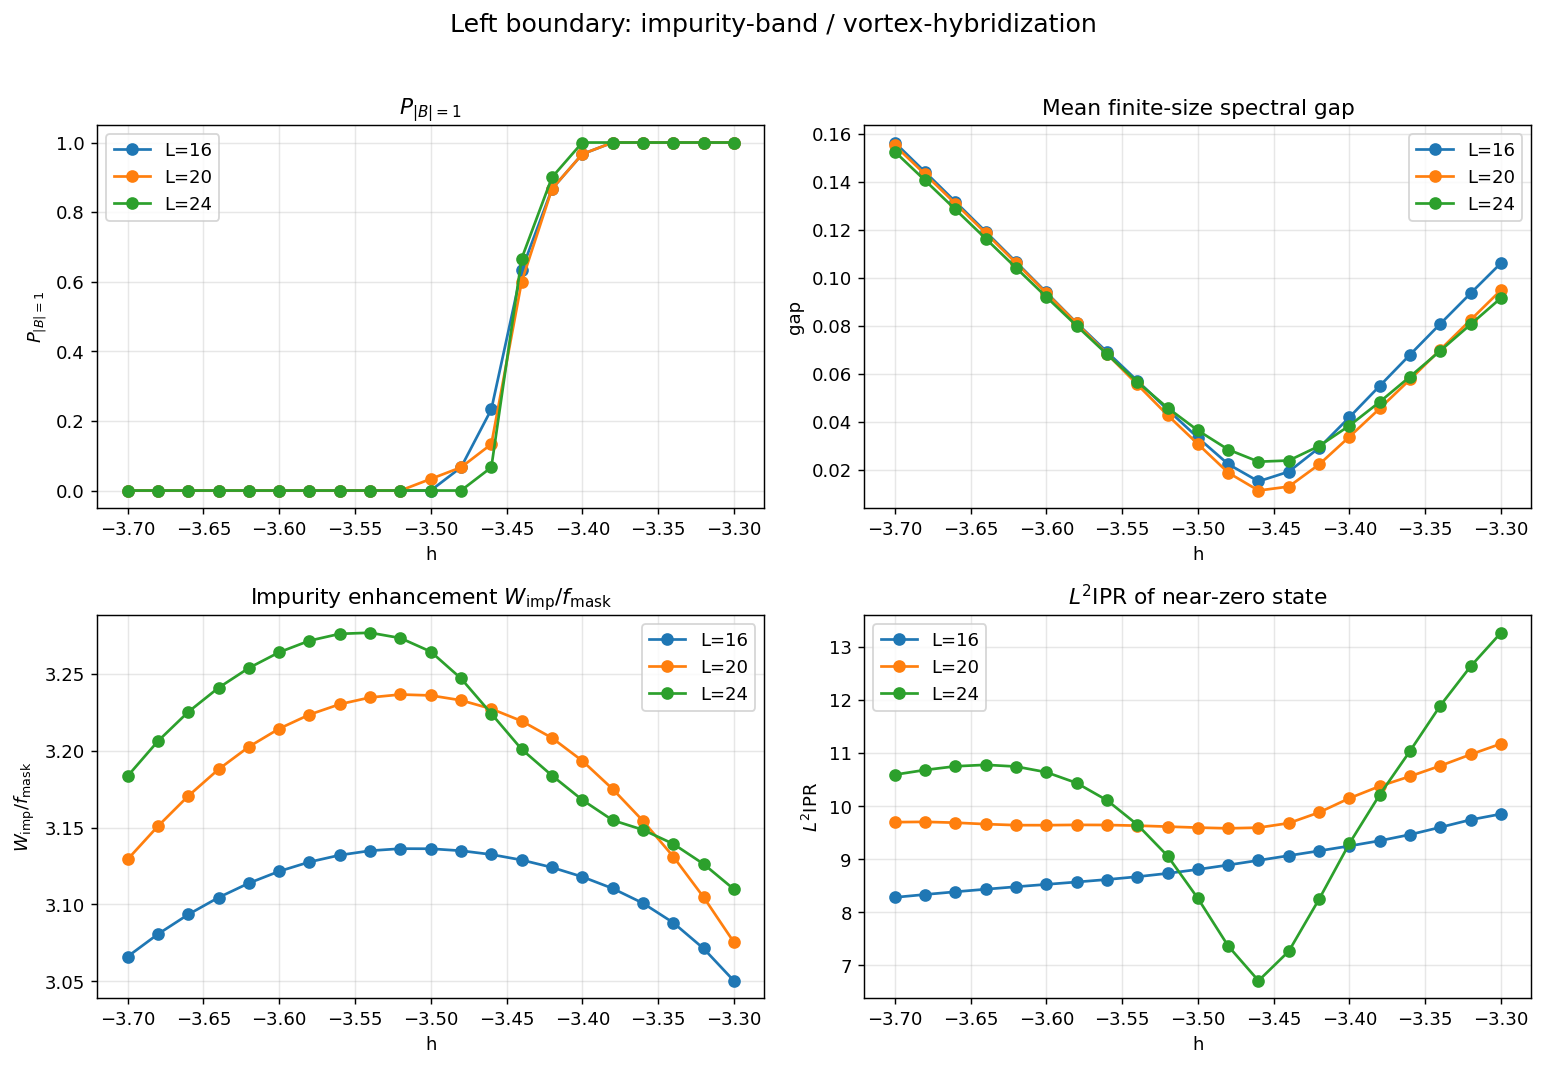

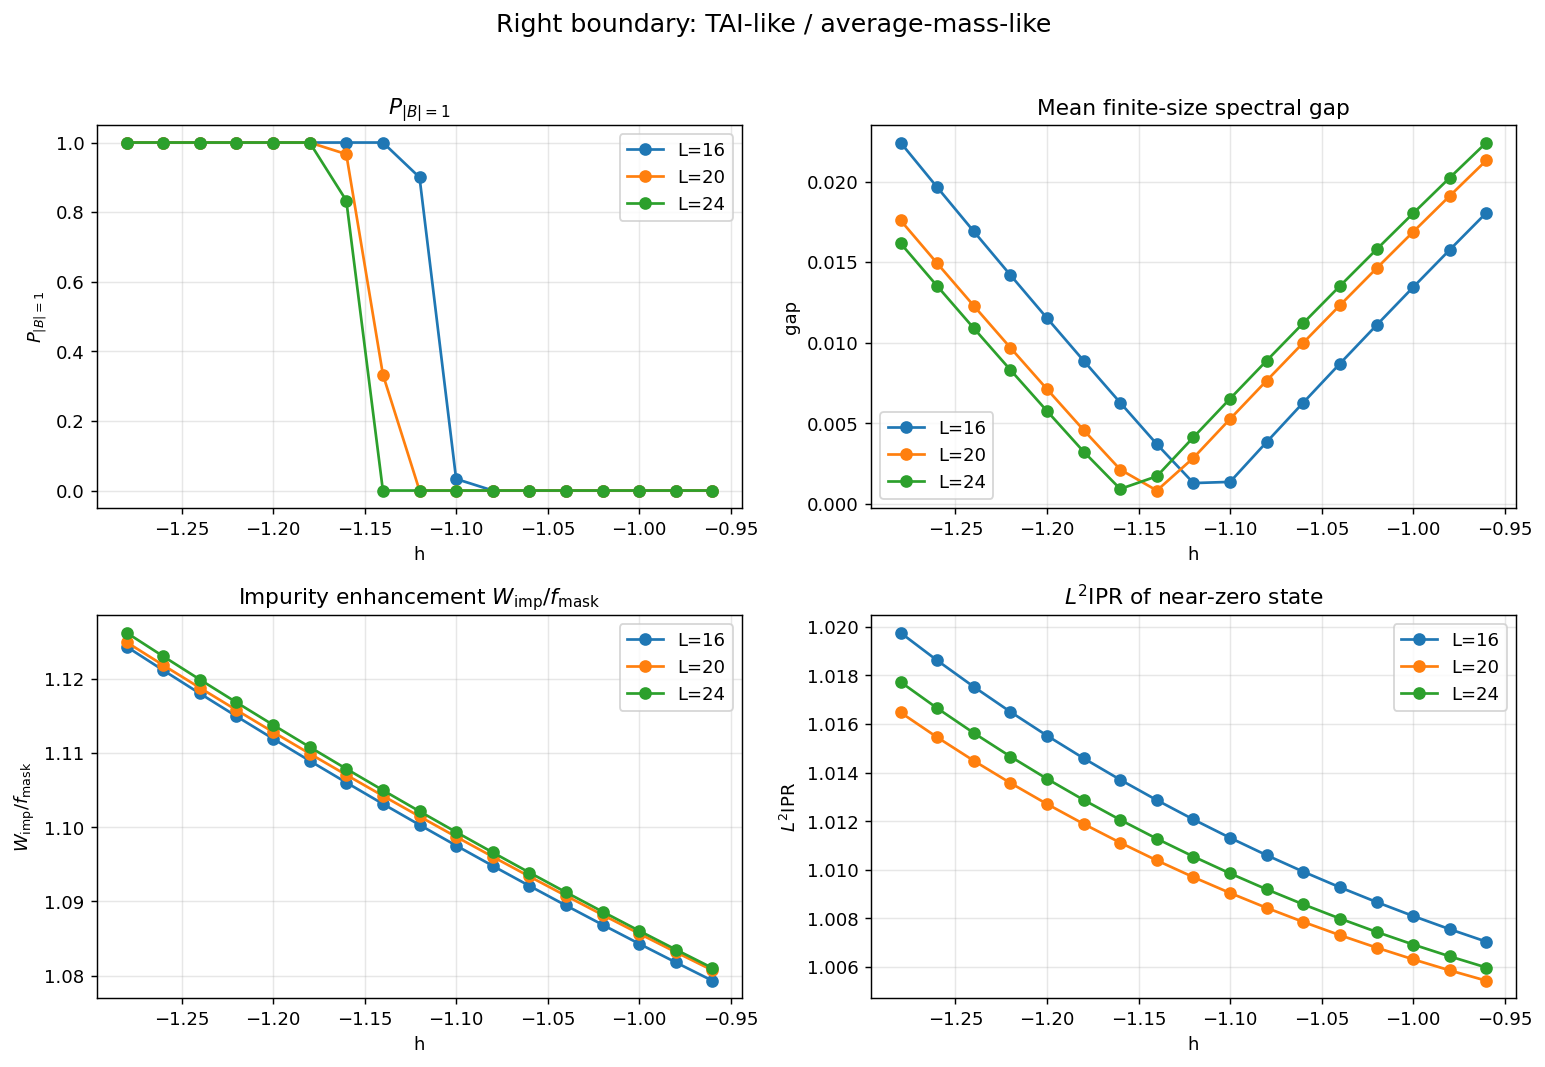

In [6]:
import matplotlib.pyplot as plt

def plot_window(summary, hmin, hmax, title):
    dwin = summary[(summary["h"] >= hmin) & (summary["h"] <= hmax)].copy()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=130)

    for L in sorted(dwin["L"].unique()):
        d = dwin[dwin["L"] == L].sort_values("h")

        axes[0, 0].plot(d["h"], d["P_top_abs"], marker="o", label=f"L={L}")
        axes[0, 1].plot(d["h"], d["mean_gap"], marker="o", label=f"L={L}")
        axes[1, 0].plot(d["h"], d["mean_Wimp_ratio"], marker="o", label=f"L={L}")
        axes[1, 1].plot(d["h"], d["mean_IPR0_scaled_L2"], marker="o", label=f"L={L}")

    axes[0, 0].set_title(r"$P_{|B|=1}$")
    axes[0, 0].set_ylabel(r"$P_{|B|=1}$")

    axes[0, 1].set_title("Mean finite-size spectral gap")
    axes[0, 1].set_ylabel("gap")

    axes[1, 0].set_title(r"Impurity enhancement $W_{\rm imp}/f_{\rm mask}$")
    axes[1, 0].set_ylabel(r"$W_{\rm imp}/f_{\rm mask}$")

    axes[1, 1].set_title(r"$L^2 \mathrm{IPR}$ of near-zero state")
    axes[1, 1].set_ylabel(r"$L^2 \mathrm{IPR}$")

    for ax in axes.flat:
        ax.set_xlabel("h")
        ax.grid(True, alpha=0.3)
        ax.legend()

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_window(
    summary_fine,
    hmin=-3.70,
    hmax=-3.30,
    title="Left boundary: impurity-band / vortex-hybridization"
)

plot_window(
    summary_fine,
    hmin=-1.28,
    hmax=-0.96,
    title="Right boundary: TAI-like / average-mass-like"
)

In [7]:
def estimate_h_at_probability(
    summary,
    L,
    h_min,
    h_max,
    prob_col="P_top_abs",
    target=0.5,
):
    d = summary[
        (summary["L"] == L)
        & (summary["h"] >= h_min)
        & (summary["h"] <= h_max)
    ].sort_values("h")

    hs = d["h"].to_numpy(dtype=float)
    ps = d[prob_col].to_numpy(dtype=float)

    if len(hs) < 2:
        return np.nan

    for i in range(len(hs) - 1):
        y1 = ps[i] - target
        y2 = ps[i + 1] - target

        if abs(y1) < 1e-12:
            return hs[i]

        if y1 * y2 < 0:
            return hs[i] + (target - ps[i]) * (hs[i + 1] - hs[i]) / (ps[i + 1] - ps[i])

    return np.nan


def estimate_boundary_table(summary):
    rows = []

    for L in sorted(summary["L"].unique()):
        # Left transition: P goes 0 -> 1
        hL_25 = estimate_h_at_probability(summary, L, -3.70, -3.30, target=0.25)
        hL_50 = estimate_h_at_probability(summary, L, -3.70, -3.30, target=0.50)
        hL_75 = estimate_h_at_probability(summary, L, -3.70, -3.30, target=0.75)

        # Right transition: P goes 1 -> 0
        hR_25 = estimate_h_at_probability(summary, L, -1.28, -0.96, target=0.25)
        hR_50 = estimate_h_at_probability(summary, L, -1.28, -0.96, target=0.50)
        hR_75 = estimate_h_at_probability(summary, L, -1.28, -0.96, target=0.75)

        rows.append({
            "L": L,

            "hL_P25": hL_25,
            "hL_P50": hL_50,
            "hL_P75": hL_75,
            "width_left_25_75": abs(hL_75 - hL_25) if np.isfinite(hL_75) and np.isfinite(hL_25) else np.nan,

            "hR_P25": hR_25,
            "hR_P50": hR_50,
            "hR_P75": hR_75,
            "width_right_25_75": abs(hR_75 - hR_25) if np.isfinite(hR_75) and np.isfinite(hR_25) else np.nan,
        })

    return pd.DataFrame(rows)


boundary_table = estimate_boundary_table(summary_fine)
display(boundary_table)
boundary_table.to_csv("q wz_fine_scan_boundary_estimates.csv".replace(" ", ""), index=False)

,L,hL_P25,hL_P50,hL_P75,width_left_25_75,hR_P25,hR_P50,hR_P75,width_right_25_75
0,16,-3.459167,-3.446667,-3.430000,0.029167,-1.105,-1.110769,-1.116538,0.011538
1,20,-3.455000,-3.444286,-3.428750,0.026250,-1.135,-1.145263,-1.153158,0.018158
2,24,-3.453889,-3.445556,-3.432857,0.021032,-1.146,-1.152000,-1.158000,0.012000


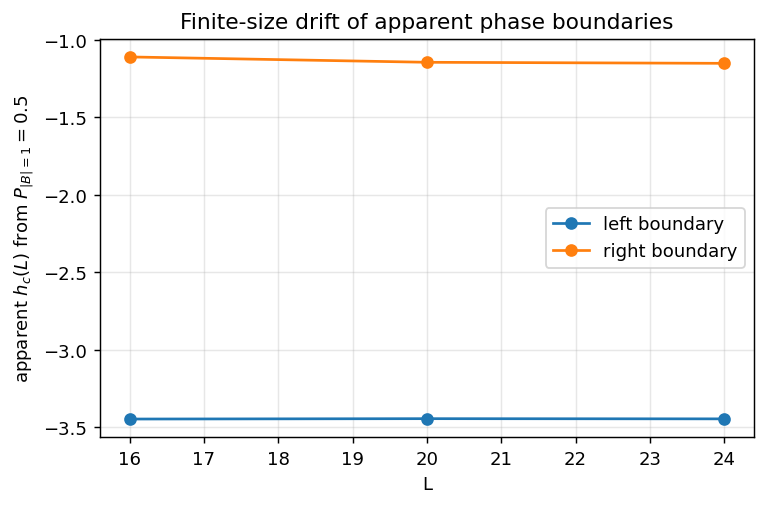

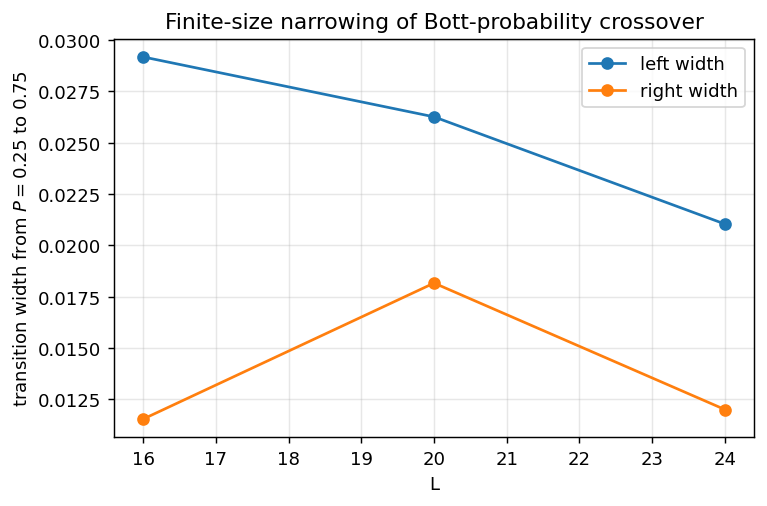

In [8]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=130)

ax.plot(boundary_table["L"], boundary_table["hL_P50"], marker="o", label="left boundary")
ax.plot(boundary_table["L"], boundary_table["hR_P50"], marker="o", label="right boundary")

ax.set_xlabel("L")
ax.set_ylabel(r"apparent $h_c(L)$ from $P_{|B|=1}=0.5$")
ax.set_title("Finite-size drift of apparent phase boundaries")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4), dpi=130)

ax.plot(boundary_table["L"], boundary_table["width_left_25_75"], marker="o", label="left width")
ax.plot(boundary_table["L"], boundary_table["width_right_25_75"], marker="o", label="right width")

ax.set_xlabel("L")
ax.set_ylabel(r"transition width from $P=0.25$ to $0.75$")
ax.set_title("Finite-size narrowing of Bott-probability crossover")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()